In [1]:
import pandas as pd
import numpy as np


df = pd.read_csv("Employee_HR.csv")

print(df.head())

    EmpId  Satisfaction  Evaluation  number_of_projects  average_montly_hours  \
0  780152           3.8         5.3                   2                   157   
1  780153           8.0         8.6                   5                   262   
2  780154           1.1         8.8                   7                   272   
3  780155           7.2         8.7                   5                   223   
4  780156           3.7         5.2                   2                   159   

   time_spent_company  work_accident  Promotion Department  Salary_INR  Churn  
0                   3              0          0      sales       11053      1  
1                   6              0          0      sales       54063      1  
2                   4              0          0      sales       61300      1  
3                   5              0          0      sales       20647      1  
4                   3              0          0      sales       17808      1  


In [2]:
print(df.shape)
print(df.columns)
print(df.dtypes)

(14999, 11)
Index(['EmpId', 'Satisfaction', 'Evaluation', 'number_of_projects',
       'average_montly_hours', 'time_spent_company', 'work_accident',
       'Promotion', 'Department', 'Salary_INR', 'Churn'],
      dtype='str')
EmpId                     int64
Satisfaction            float64
Evaluation              float64
number_of_projects        int64
average_montly_hours      int64
time_spent_company        int64
work_accident             int64
Promotion                 int64
Department                  str
Salary_INR                int64
Churn                     int64
dtype: object


In [3]:
df.isnull().sum()

EmpId                   0
Satisfaction            0
Evaluation              0
number_of_projects      0
average_montly_hours    0
time_spent_company      0
work_accident           0
Promotion               0
Department              0
Salary_INR              0
Churn                   0
dtype: int64

In [4]:
print("Duplicate rows:", df.duplicated().sum())

print("Duplicate EmpIds:", df["EmpId"].duplicated().sum())

Duplicate rows: 0
Duplicate EmpIds: 0


In [5]:
df["Department"].value_counts()

Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

In [6]:
df["Churn"].value_counts()

Churn
0    11428
1     3571
Name: count, dtype: int64

In [7]:
df["Promotion"].value_counts()

Promotion
0    14680
1      319
Name: count, dtype: int64

In [8]:
df.describe()

,EmpId,Satisfaction,Evaluation,number_of_projects,average_montly_hours,time_spent_company,work_accident,Promotion,Salary_INR,Churn
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,787651.000000,6.128335,7.161017,3.803054,201.050337,3.498233,0.144610,0.021268,62742.699913,0.238083
std,4329.982679,2.486307,1.711691,1.232592,49.943099,1.460136,0.351719,0.144281,66486.116149,0.425924
min,780152.000000,0.900000,3.600000,2.000000,96.000000,2.000000,0.000000,0.000000,10000.000000,0.000000
25%,783901.500000,4.400000,5.600000,3.000000,156.000000,3.000000,0.000000,0.000000,25248.000000,0.000000
50%,787651.000000,6.400000,7.200000,4.000000,200.000000,3.000000,0.000000,0.000000,41721.000000,0.000000
75%,791400.500000,8.200000,8.700000,5.000000,245.000000,4.000000,0.000000,0.000000,76354.000000,0.000000
max,795150.000000,10.000000,10.000000,7.000000,310.000000,10.000000,1.000000,1.000000,399930.000000,1.000000


In [9]:
# 1. Overall Employee Churn Rate

# Business Question:
# What percentage of employees have left the company?

churned_employees = (df["Churn"] == 1).sum()
total_employees = len(df)

churn_rate = (churned_employees / total_employees) * 100

print("Overall Churn Rate:", round(churn_rate, 2), "%")


Overall Churn Rate: 23.81 %


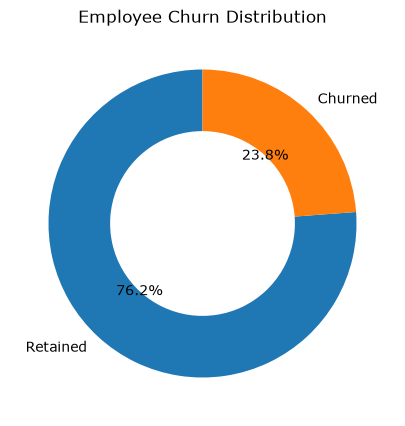

In [159]:
import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()

labels = ["Retained", "Churned"]
values = [churn_counts[0], churn_counts[1]]

plt.figure(figsize=(7, 5))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Employee Churn Distribution")

plt.show()

In [10]:
# Business Insight:
# Around 23.81% of employees have left the company, indicating a significant level of employee churn.


In [11]:
# 2. Department-wise Employee Churn Rate

# Business Question:
# Which departments have the highest employee churn rate?

department_total = df.groupby("Department")["EmpId"].count()

print(department_total)

Department
IT             1227
RandD           787
accounting      767
hr              739
management      630
marketing       858
product_mng     902
sales          4140
support        2229
technical      2720
Name: EmpId, dtype: int64


In [12]:
department_churned = df[df["Churn"] == 1].groupby("Department")["EmpId"].count()

print(department_churned)

Department
IT              273
RandD           121
accounting      204
hr              215
management       91
marketing       203
product_mng     198
sales          1014
support         555
technical       697
Name: EmpId, dtype: int64


In [13]:
department_churn_rate = (department_churned / department_total) * 100



department_churn_rate = department_churn_rate.sort_values(ascending=False)

print(department_churn_rate.round(2))

Department
hr             29.09
accounting     26.60
technical      25.62
support        24.90
sales          24.49
marketing      23.66
IT             22.25
product_mng    21.95
RandD          15.37
management     14.44
Name: EmpId, dtype: float64


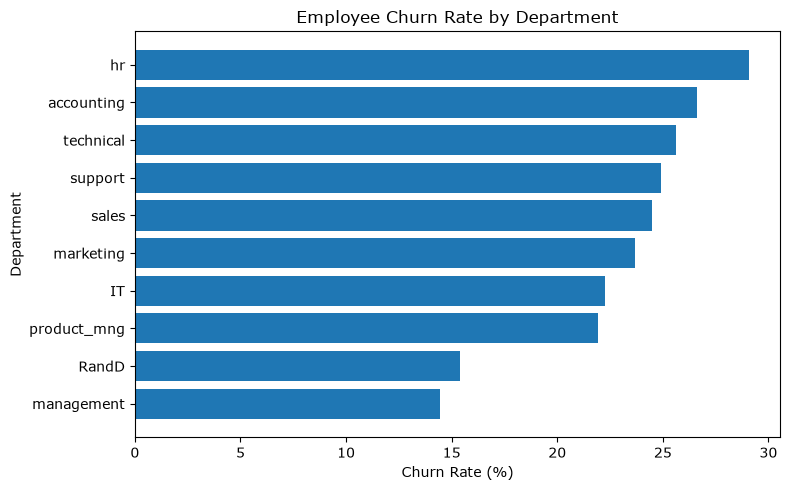

In [162]:


department_churn_rate = department_churn_rate.sort_values(
    by="Churn_Rate"
)

plt.figure(figsize=(8, 5))

plt.barh(
    department_churn_rate["Department"],
    department_churn_rate["Churn_Rate"]
)

plt.title("Employee Churn Rate by Department")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

In [14]:
# Business Insight:
# HR has the highest churn rate at 29.09%, followed by Accounting at 26.60%.
# Management has the lowest churn rate at 14.44%.

In [15]:
# 3. Promotion Status vs Employee Churn

# Business Question:
# Does employee promotion status relate to employee churn?

promotion_total = df.groupby("Promotion")["EmpId"].count()

print(promotion_total)

Promotion
0    14680
1      319
Name: EmpId, dtype: int64


In [16]:
promotion_churned = df[df["Churn"] == 1].groupby("Promotion")["EmpId"].count()

print(promotion_churned)

Promotion
0    3552
1      19
Name: EmpId, dtype: int64


In [17]:
promotion_churn_rate = (promotion_churned / promotion_total) * 100

print(promotion_churn_rate.round(2))

Promotion
0    24.20
1     5.96
Name: EmpId, dtype: float64


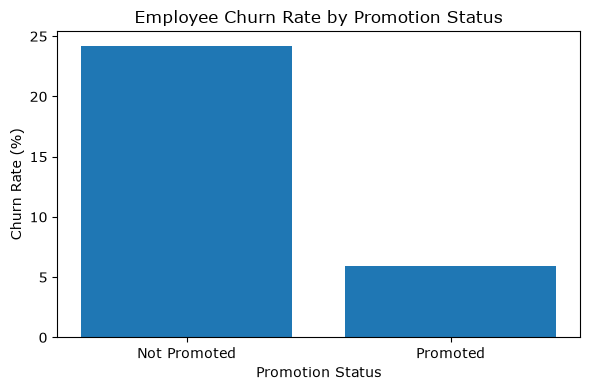

In [165]:
plt.figure(figsize=(6, 4))

plt.bar(
    promotion_churn_rate["Promotion_Status"],
    promotion_churn_rate["Churn_Rate"]
)

plt.title("Employee Churn Rate by Promotion Status")
plt.xlabel("Promotion Status")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [18]:
# Business Insight:
# Employees who were not promoted had a churn rate of 24.20%,
# compared with 5.96% among promoted employees.
# This suggests that promotion status is associated with lower employee churn.

In [19]:
# 4. Employee Satisfaction vs Churn

# Business Question:
# How does employee satisfaction relate to employee churn?

# Create satisfaction bands

conditions = [
    df["Satisfaction"] < 4,
    df["Satisfaction"].between(4, 7),
    df["Satisfaction"] > 7
]

choices = ["Low", "Medium", "High"]

df["Satisfaction_Band"] = np.select(
    conditions,
    choices,
    default="Unknown"
)

print(df[["Satisfaction", "Satisfaction_Band"]].head())



   Satisfaction Satisfaction_Band
0           3.8               Low
1           8.0              High
2           1.1               Low
3           7.2              High
4           3.7               Low


In [20]:
satisfaction_total = df.groupby("Satisfaction_Band")["EmpId"].count()

print(satisfaction_total)

Satisfaction_Band
High      6298
Low       2915
Medium    5786
Name: EmpId, dtype: int64


In [21]:
satisfaction_churned = (
    df[df["Churn"] == 1]
    .groupby("Satisfaction_Band")["EmpId"]
    .count()
)

print(satisfaction_churned)

Satisfaction_Band
High       933
Low       1566
Medium    1072
Name: EmpId, dtype: int64


In [22]:
satisfaction_churn_rate = (satisfaction_churned / satisfaction_total) * 100

print(satisfaction_churn_rate.round(2))

Satisfaction_Band
High      14.81
Low       53.72
Medium    18.53
Name: EmpId, dtype: float64


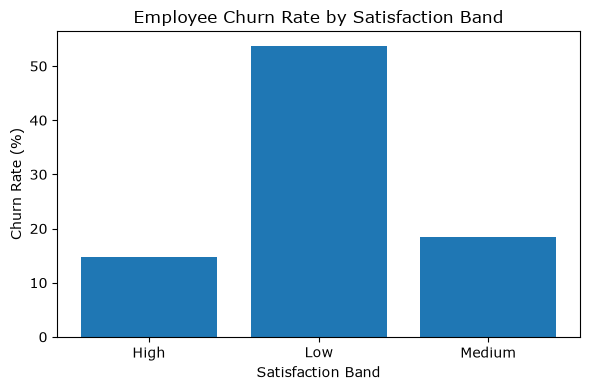

In [169]:

plt.figure(figsize=(6, 4))

plt.bar(
    satisfaction_churn_rate.index,
    satisfaction_churn_rate.values
)

plt.title("Employee Churn Rate by Satisfaction Band")
plt.xlabel("Satisfaction Band")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [23]:
# Business Insight:
# Employees with low satisfaction had the highest churn rate at 53.72%.
# Medium and high satisfaction employees had much lower churn rates
# of 18.53% and 14.81%, respectively.
# This indicates a strong association between low satisfaction and employee churn.

In [24]:
# 5. Monthly Working Hours vs Employee Churn

# Business Question:
# How does average monthly working hours relate to employee churn?


conditions =[
    df["average_montly_hours"] < 170,
    df["average_montly_hours"].between(170, 240),
    df["average_montly_hours"] > 240  
]

choices = ["Low Hours", "Normal Hours", "High Hours"]

df["Workload_Band"] = np.select(
    conditions,
    choices,
    default="Unknown"
)

print(df[["average_montly_hours", "Workload_Band"]].head())

   average_montly_hours Workload_Band
0                   157     Low Hours
1                   262    High Hours
2                   272    High Hours
3                   223  Normal Hours
4                   159     Low Hours


In [25]:
workload_total = df.groupby("Workload_Band")["EmpId"].count()

print(workload_total)

Workload_Band
High Hours      4208
Low Hours       5097
Normal Hours    5694
Name: EmpId, dtype: int64


In [26]:
workload_churned = (
    df[df["Churn"] == 1]
    .groupby("Workload_Band")["EmpId"]
    .count()
)

print(workload_churned)

Workload_Band
High Hours      1521
Low Hours       1609
Normal Hours     441
Name: EmpId, dtype: int64


In [27]:
workload_churn_rate = (workload_churned / workload_total) * 100

workload_churn_rate = workload_churn_rate.sort_values(ascending=False)

print(workload_churn_rate.round(2))

Workload_Band
High Hours      36.15
Low Hours       31.57
Normal Hours     7.74
Name: EmpId, dtype: float64


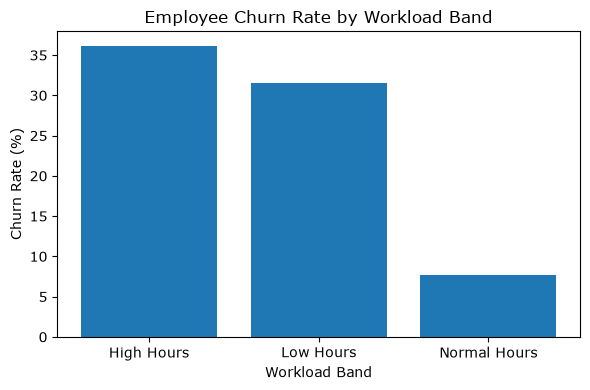

In [171]:
plt.figure(figsize=(6, 4))

plt.bar(
    workload_churn_rate.index,
    workload_churn_rate.values
)

plt.title("Employee Churn Rate by Workload Band")
plt.xlabel("Workload Band")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [28]:
# Business Insight:
# Employees working high monthly hours had the highest churn rate at 36.15%,
# followed by low-hours employees at 31.57%.
# Employees with normal working hours had the lowest churn rate at 7.74%.
# This indicates that workload level is associated with employee churn in this dataset.

In [29]:
# 6. Salary Band vs Employee Churn

# Business Question:
# How does salary level relate to employee churn?

salary_stats = df["Salary_INR"].describe()

print(salary_stats)

count     14999.000000
mean      62742.699913
std       66486.116149
min       10000.000000
25%       25248.000000
50%       41721.000000
75%       76354.000000
max      399930.000000
Name: Salary_INR, dtype: float64


In [30]:
low_cutoff = df["Salary_INR"].quantile(0.33)
high_cutoff = df["Salary_INR"].quantile(0.66)

print(low_cutoff)
print(high_cutoff)

30280.38
63410.08


In [31]:
conditions = [
    df["Salary_INR"] < low_cutoff,
    df["Salary_INR"] <= high_cutoff
]

choices = [
    "Low Salary",
    "Medium Salary"
]

df["Salary_Band"] = np.select(
    conditions,
    choices,
    default="High Salary"
)

print(df[["Salary_INR", "Salary_Band"]].head(10))

   Salary_INR    Salary_Band
0       11053     Low Salary
1       54063  Medium Salary
2       61300  Medium Salary
3       20647     Low Salary
4       17808     Low Salary
5       38805  Medium Salary
6       32471  Medium Salary
7       32472  Medium Salary
8       36981  Medium Salary
9       10026     Low Salary


In [32]:
churn_by_salary = df.groupby("Salary_Band")["Churn"].mean() * 100

print(churn_by_salary)

Salary_Band
High Salary      16.686275
Low Salary       29.656566
Medium Salary    25.298040
Name: Churn, dtype: float64


In [33]:
salary_churn_summary = df.groupby("Salary_Band")["Churn"].agg(
    Employees="count",
    Churned="sum"
)

salary_churn_summary["Churn_Rate"] = (
    salary_churn_summary["Churned"] /
    salary_churn_summary["Employees"] * 100
)

print(salary_churn_summary)

               Employees  Churned  Churn_Rate
Salary_Band                                  
High Salary         5100      851   16.686275
Low Salary          4950     1468   29.656566
Medium Salary       4949     1252   25.298040


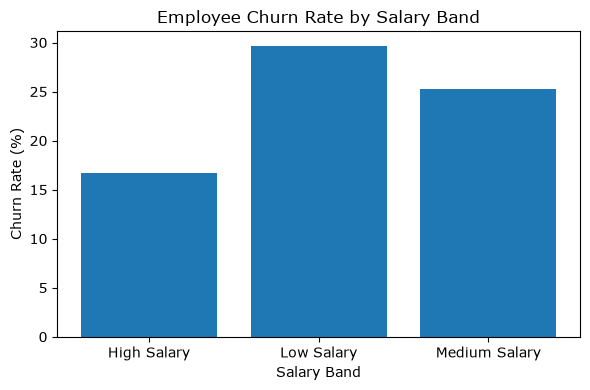

In [175]:
plt.figure(figsize=(6, 4))

plt.bar(
    salary_churn_summary.index,
    salary_churn_summary["Churn_Rate"]
)

plt.title("Employee Churn Rate by Salary Band")
plt.xlabel("Salary Band")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [34]:
# Business Insight:
# Churn decreases as salary level increases.
# Low-salary employees have the highest churn (29.66%), while high-salary employees
# have the lowest churn (16.69%), indicating a strong association between compensation
# and employee retention.

In [35]:
# 7. Number of Projects vs Employee Churn

# Business Question:
# How does the number of projects assigned to an employee relate to employee churn?

# Business Objective:
# Analyze whether employees handling a higher number of projects have higher
# churn rates compared with employees handling fewer projects.


project_churn = df.groupby("number_of_projects")["Churn"].mean() * 100

print(project_churn)

number_of_projects
2     65.619765
3      1.775586
4      9.369989
5     22.165882
6     55.792164
7    100.000000
Name: Churn, dtype: float64


In [36]:
project_summary = df.groupby("number_of_projects")["Churn"].agg(
    Employees="count",
    Churned="sum"
)

project_summary["Churn_Rate"] = (
    project_summary["Churned"] /
    project_summary["Employees"] * 100
)

print(project_summary)

                    Employees  Churned  Churn_Rate
number_of_projects                                
2                        2388     1567   65.619765
3                        4055       72    1.775586
4                        4365      409    9.369989
5                        2761      612   22.165882
6                        1174      655   55.792164
7                         256      256  100.000000


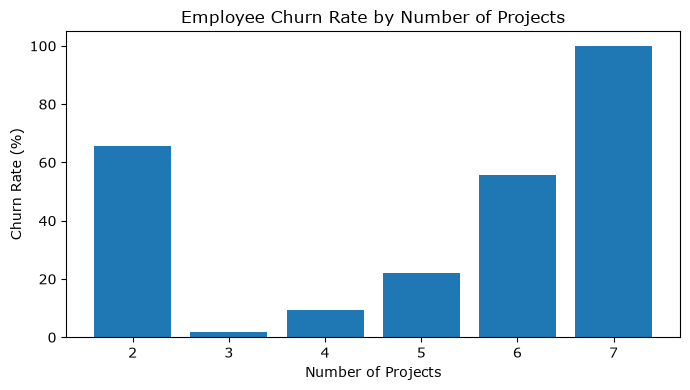

In [177]:
plt.figure(figsize=(7, 4))

plt.bar(
    project_summary.index.astype(str),
    project_summary["Churn_Rate"]
)

plt.title("Employee Churn Rate by Number of Projects")
plt.xlabel("Number of Projects")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [37]:
# Business Insight:
# Churn is lowest among employees handling 3–4 projects, at 1.78% and 9.37% respectively.
# Churn increases sharply for employees handling 5–7 projects, reaching 55.79% for 6 projects
# and 100% for 7 projects. Employees with only 2 projects also show high churn at 65.62%.
# This suggests that both under-utilization and excessive project workload are associated
# with higher employee churn. The 7-project result should be interpreted cautiously because
# the group contains only 256 employees.

In [38]:
# 8. Tenure vs Employee Churn

# Business Question:
# How does employee tenure relate to employee churn?

tenure_churn = df.groupby("time_spent_company")["Churn"].mean() * 100

print(tenure_churn)

time_spent_company
2      1.633785
3     24.615862
4     34.806414
5     56.551256
6     29.108635
7      0.000000
8      0.000000
10     0.000000
Name: Churn, dtype: float64


In [39]:
tenure_summary = df.groupby("time_spent_company")["Churn"].agg(
    Employees="count",
    Churned="sum"
)

tenure_summary["Churn_Rate"] = (
    tenure_summary["Churned"] /
    tenure_summary["Employees"] * 100
)

print(tenure_summary)

                    Employees  Churned  Churn_Rate
time_spent_company                                
2                        3244       53    1.633785
3                        6443     1586   24.615862
4                        2557      890   34.806414
5                        1473      833   56.551256
6                         718      209   29.108635
7                         188        0    0.000000
8                         162        0    0.000000
10                        214        0    0.000000


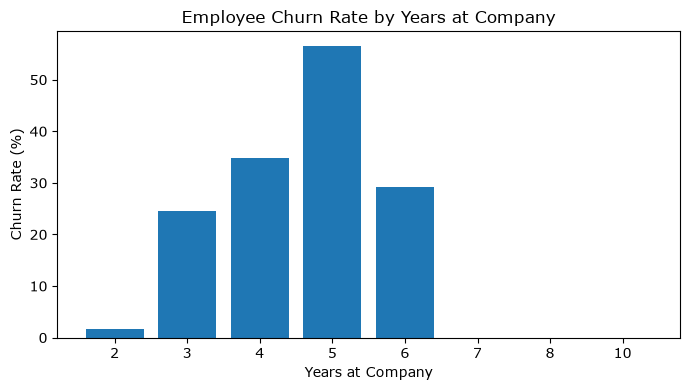

In [179]:
plt.figure(figsize=(7, 4))

plt.bar(
    tenure_summary.index.astype(str),
    tenure_summary["Churn_Rate"]
)

plt.title("Employee Churn Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [40]:
# Business Insight:
# Employee churn increases substantially as tenure rises from 2 to 5 years,
# reaching the highest churn rate of 56.55% among employees with 5 years
# of tenure. Churn then declines to 29.11% at 6 years and is 0% for the
# 7, 8, and 10-year groups. This suggests that the 3–5 year tenure period
# may be a critical retention stage, particularly around the 5-year mark.
# The 0% churn in longer-tenure groups should be interpreted cautiously
# because these groups contain relatively few employees.

In [41]:
# 9. Work Accident vs Employee Churn

# Business Question:
# How does experiencing a work accident relate to employee churn?

accident_churn = df.groupby("work_accident")["Churn"].mean() * 100

print(accident_churn)

work_accident
0    26.515978
1     7.791609
Name: Churn, dtype: float64


In [42]:
accident_summary = df.groupby("work_accident")["Churn"].agg(
    Employees="count",
    Churned="sum"
)

accident_summary["Churn_Rate"] = (
    accident_summary["Churned"] /
    accident_summary["Employees"] * 100
)

print(accident_summary)

               Employees  Churned  Churn_Rate
work_accident                                
0                  12830     3402   26.515978
1                   2169      169    7.791609


In [43]:
# Business Insight:
# Employees without a recorded work accident have a substantially higher churn
# rate (26.52%) compared with employees who experienced a work accident (7.79%).
# This indicates a strong association between work-accident status and employee
# churn in the dataset. However, this relationship should not be interpreted
# as causal and may be influenced by other employee or workplace factors.

In [44]:
# 10. Evaluation Score vs Employee Churn

# Business Question:
# How does employee performance evaluation relate to employee churn?

low_eval = df["Evaluation"].quantile(0.33)
high_eval = df["Evaluation"].quantile(0.66)

conditions = [
    df["Evaluation"] < low_eval,
    df["Evaluation"] <= high_eval
]

choices = [
    "Low Evaluation",
    "Medium Evaluation"
]

df["Evaluation_Band"] = np.select(
    conditions,
    choices,
    default="High Evaluation"
)

evaluation_churn = df.groupby("Evaluation_Band")["Churn"].mean() * 100

print(evaluation_churn)

Evaluation_Band
High Evaluation      31.959176
Low Evaluation       33.909743
Medium Evaluation     6.958175
Name: Churn, dtype: float64


In [45]:
evaluation_summary = df.groupby("Evaluation_Band")["Churn"].agg(
    Employees="count",
    Churned="sum"
)

evaluation_summary["Churn_Rate"] = (
    evaluation_summary["Churned"] /
    evaluation_summary["Employees"] * 100
)

print(evaluation_summary)

                   Employees  Churned  Churn_Rate
Evaluation_Band                                  
High Evaluation         4997     1597   31.959176
Low Evaluation          4742     1608   33.909743
Medium Evaluation       5260      366    6.958175


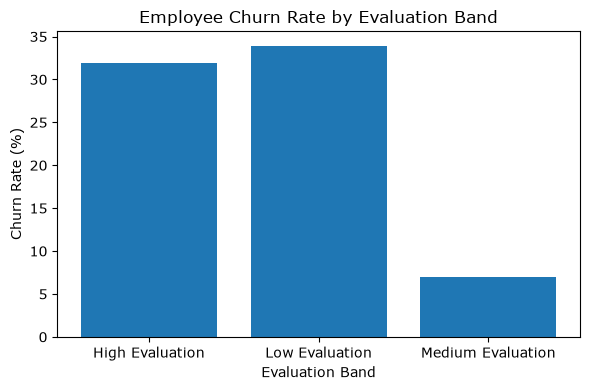

In [181]:
plt.figure(figsize=(6, 4))

plt.bar(
    evaluation_summary.index,
    evaluation_summary["Churn_Rate"]
)

plt.title("Employee Churn Rate by Evaluation Band")
plt.xlabel("Evaluation Band")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

In [46]:
# Business Insight:
# Employee churn shows a non-linear relationship with performance evaluation.
# Employees in the Medium Evaluation band have the lowest churn rate (6.96%),
# while Low Evaluation and High Evaluation employees have substantially higher
# churn rates of 33.91% and 31.96%, respectively. This suggests that both
# lower- and higher-evaluated employees may have different retention risks,
# requiring further investigation into workload, compensation, promotions,
# and career growth factors.

In [47]:
# 11. Satisfaction × Evaluation vs Employee Churn

# Business Question:
# How does the combination of employee satisfaction and performance evaluation
# relate to employee churn?

satisfaction_median = df["Satisfaction"].median()
evaluation_median = df["Evaluation"].median()

df["Employee_Segment"] = np.select(
    [
        (df["Satisfaction"] < satisfaction_median) &
        (df["Evaluation"] < evaluation_median),

        (df["Satisfaction"] < satisfaction_median) &
        (df["Evaluation"] >= evaluation_median),

        (df["Satisfaction"] >= satisfaction_median) &
        (df["Evaluation"] < evaluation_median)
    ],
    [
        "Low Satisfaction - Low Evaluation",
        "Low Satisfaction - High Evaluation",
        "High Satisfaction - Low Evaluation"
    ],
    default="High Satisfaction - High Evaluation"
)

segment_churn = df.groupby("Employee_Segment")["Churn"].mean() * 100

print(segment_churn.sort_values(ascending=False))

Employee_Segment
Low Satisfaction - Low Evaluation      39.353750
Low Satisfaction - High Evaluation     30.749922
High Satisfaction - High Evaluation    20.660783
High Satisfaction - Low Evaluation      1.417129
Name: Churn, dtype: float64


In [48]:
segment_summary = df.groupby("Employee_Segment")["Churn"].agg(
    Employees="count",
    Churned="sum"
)

segment_summary["Churn_Rate"] = (
    segment_summary["Churned"] /
    segment_summary["Employees"] * 100
)

print(segment_summary.sort_values("Churn_Rate", ascending=False))

                                     Employees  Churned  Churn_Rate
Employee_Segment                                                   
Low Satisfaction - Low Evaluation         4147     1632   39.353750
Low Satisfaction - High Evaluation        3187      980   30.749922
High Satisfaction - High Evaluation       4419      913   20.660783
High Satisfaction - Low Evaluation        3246       46    1.417129


In [49]:
# Business Insight:
# Employee churn varies substantially across satisfaction and evaluation segments.
# Employees with low satisfaction and low evaluation have the highest churn rate
# (39.35%), followed by low satisfaction and high evaluation employees (30.75%).
# High satisfaction and low evaluation employees have the lowest churn (1.42%),
# while high satisfaction and high evaluation employees have 20.66% churn.
# This suggests that employee satisfaction is strongly associated with retention,
# while performance evaluation alone does not necessarily indicate higher churn.

In [50]:
# 12. Department × Salary Band vs Employee Churn

# Business Question:
# Does the relationship between salary level and churn differ across departments?

dept_salary_churn = (
    df.groupby(["Department", "Salary_Band"])["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn_Rate")
)

print(dept_salary_churn)

     Department    Salary_Band  Churn_Rate
0            IT    High Salary   16.706444
1            IT     Low Salary   29.368932
2            IT  Medium Salary   20.707071
3         RandD    High Salary   15.018315
4         RandD     Low Salary   15.969582
5         RandD  Medium Salary   15.139442
6    accounting    High Salary   25.179856
7    accounting     Low Salary   25.213675
8    accounting  Medium Salary   29.411765
9            hr    High Salary   27.985075
10           hr     Low Salary   28.125000
11           hr  Medium Salary   31.174089
12   management    High Salary    5.681818
13   management     Low Salary   32.710280
14   management  Medium Salary   21.052632
15    marketing    High Salary   15.548780
16    marketing     Low Salary   31.205674
17    marketing  Medium Salary   25.806452
18  product_mng    High Salary   17.931034
19  product_mng     Low Salary   25.377644
20  product_mng  Medium Salary   22.064057
21        sales    High Salary   13.937548
22        s

In [51]:
# Business Insight:
# Salary-related churn varies across departments.
# Low-salary employees generally have higher churn than high-salary employees,
# with Sales (33.36%), Support (33.29%), and Management (32.71%) showing the
# highest low-salary churn. In contrast, high-salary employees in Management
# have the lowest churn rate (5.68%).
# This suggests that compensation-related retention risk differs by department
# and may require department-specific retention strategies.

In [52]:
# 13. Work Accident × Department vs Employee Churn

# Business Question:
# Does work-accident status relate differently to churn across departments?

accident_dept_churn = (
    df.groupby(["Department", "work_accident"])["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn_Rate")
)

print(accident_dept_churn)

     Department  work_accident  Churn_Rate
0            IT              0   24.835372
1            IT              1    5.487805
2         RandD              0   16.998469
3         RandD              1    7.462687
4    accounting              0   29.061103
5    accounting              1    9.375000
6            hr              0   32.000000
7            hr              1    7.865169
8    management              0   16.318786
9    management              1    4.854369
10    marketing              0   26.805556
11    marketing              1    7.246377
12  product_mng              0   24.545455
13  product_mng              1    6.818182
14        sales              0   27.244582
15        sales              1    7.836457
16      support              0   27.813163
17      support              1    8.985507
18    technical              0   28.388200
19    technical              1    8.661417


In [53]:
# Business Insight:
# Employees without a recorded work accident consistently show higher churn
# than employees with a recorded accident across every department.
# HR has the highest churn among employees without an accident (32.00%),
# followed by Accounting (29.06%) and Technical (28.39%).
# This indicates that the association between work-accident status and churn
# is consistent across departments, although the relationship should not be
# interpreted as causal and may reflect other employee or workplace factors.

In [54]:
# 14. Promotion × Department vs Employee Churn

# Business Question:
# Does the relationship between promotion status and churn vary across departments?


promotion_dept_churn = (
    df.groupby(["Department", "Promotion"])["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn_Rate")
)

print(promotion_dept_churn)

     Department  Promotion  Churn_Rate
0            IT          0   22.058824
1            IT          1  100.000000
2         RandD          0   15.921053
3         RandD          1    0.000000
4    accounting          0   27.091633
5    accounting          1    0.000000
6            hr          0   29.696133
7            hr          1    0.000000
8    management          0   15.686275
9    management          1    4.347826
10    marketing          0   24.907975
11    marketing          1    0.000000
12  product_mng          0   21.951220
13        sales          0   24.925743
14        sales          1    7.000000
15      support          0   24.988683
16      support          1   15.000000
17    technical          0   25.780089
18    technical          1   10.714286


In [55]:
# Check employee counts for each Department × Promotion group

promotion_dept_count = (
    df.groupby(["Department", "Promotion"])["Churn"]
    .agg(
        Employees="count",
        Churned="sum"
    )
    .reset_index()
)

promotion_dept_count["Churn_Rate"] = (
    promotion_dept_count["Churned"]
    / promotion_dept_count["Employees"]
    * 100
)

print(promotion_dept_count)

     Department  Promotion  Employees  Churned  Churn_Rate
0            IT          0       1224      270   22.058824
1            IT          1          3        3  100.000000
2         RandD          0        760      121   15.921053
3         RandD          1         27        0    0.000000
4    accounting          0        753      204   27.091633
5    accounting          1         14        0    0.000000
6            hr          0        724      215   29.696133
7            hr          1         15        0    0.000000
8    management          0        561       88   15.686275
9    management          1         69        3    4.347826
10    marketing          0        815      203   24.907975
11    marketing          1         43        0    0.000000
12  product_mng          0        902      198   21.951220
13        sales          0       4040     1007   24.925743
14        sales          1        100        7    7.000000
15      support          0       2209      552   24.9886

In [56]:
# Business Insight:
# Promoted employees generally show lower churn than non-promoted employees,
# particularly in Management (4.35% vs 15.69%), Sales (7.00% vs 24.93%),
# and Technical (10.71% vs 25.78%). This suggests that career progression
# is associated with better employee retention in several departments.
# However, some department-level promotion groups are very small, so extreme
# rates such as 100% churn in IT (3 employees) and 0% churn in several
# departments should be interpreted cautiously.

In [57]:
# 15. Tenure × Salary Band vs Employee Churn

# Business Question:
# Does the relationship between salary level and churn vary across employee tenure?

tenure_salary_churn = (
    df.groupby(["time_spent_company", "Salary_Band"])["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn_Rate")
)

print(tenure_salary_churn)

    time_spent_company    Salary_Band  Churn_Rate
0                    2    High Salary    1.646447
1                    2     Low Salary    1.453488
2                    2  Medium Salary    1.795841
3                    3    High Salary   17.852162
4                    3     Low Salary   31.186284
5                    3  Medium Salary   24.789128
6                    4    High Salary   24.662577
7                    4     Low Salary   40.362812
8                    4  Medium Salary   38.720930
9                    5    High Salary   47.663551
10                   5     Low Salary   62.037037
11                   5  Medium Salary   58.217822
12                   6    High Salary   16.538462
13                   6     Low Salary   40.090090
14                   6  Medium Salary   32.627119
15                   7    High Salary    0.000000
16                   7     Low Salary    0.000000
17                   7  Medium Salary    0.000000
18                   8    High Salary    0.000000


In [58]:
# Business Insight:
# Salary-related churn risk varies substantially across employee tenure.
# Churn is particularly high around the 5-year tenure mark, reaching 62.04%
# among low-salary employees and 47.66% among high-salary employees.
# Across the 3–6 year tenure period, lower-salary employees consistently
# show higher churn than higher-salary employees.
# This suggests that compensation may be an important retention consideration
# during the mid-tenure stage, particularly around 5 years of service.
# The 0% churn observed in the 7, 8, and 10-year groups should be interpreted
# cautiously because these groups contain relatively few employees.

In [59]:
# 16. Number of Projects × Salary Band vs Employee Churn

# Business Question:
# Does the relationship between number of projects and churn vary across salary levels?

project_salary_churn = (
    df.groupby(["number_of_projects", "Salary_Band"])["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn_Rate")
)

print(project_salary_churn)

    number_of_projects    Salary_Band  Churn_Rate
0                    2    High Salary   55.172414
1                    2     Low Salary   73.333333
2                    2  Medium Salary   66.035354
3                    3    High Salary    1.506221
4                    3     Low Salary    2.138158
5                    3  Medium Salary    1.753049
6                    4    High Salary    6.010568
7                    4     Low Salary   11.603376
8                    4  Medium Salary   10.706788
9                    5    High Salary   15.296566
10                   5     Low Salary   28.349945
11                   5  Medium Salary   23.299889
12                   6    High Salary   41.839763
13                   6     Low Salary   64.164649
14                   6  Medium Salary   58.726415
15                   7    High Salary  100.000000
16                   7     Low Salary  100.000000
17                   7  Medium Salary  100.000000


In [60]:
# Business Insight:
# Churn is lowest among employees handling 3 projects, regardless of salary level,
# with rates ranging from 1.51% to 2.14%. Churn increases substantially when
# employees handle 5–6 projects, particularly among low-salary employees,
# reaching 64.16% at 6 projects.
# Employees with only 2 projects also show high churn across all salary bands.
# This suggests that both project allocation and compensation are associated
# with employee retention, with excessive project loads showing particularly
# high churn among lower-salary employees.
# The 100% churn observed for 7 projects should be interpreted cautiously
# after checking the group size.

In [61]:
# 17. Satisfaction × Salary Band vs Employee Churn

# Business Question:
# Does the relationship between satisfaction and churn vary across salary levels?

satisfaction_salary_churn = (
    df.groupby(["Satisfaction_Band", "Salary_Band"])["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn_Rate")
)

print(satisfaction_salary_churn)

  Satisfaction_Band    Salary_Band  Churn_Rate
0              High    High Salary   10.126582
1              High     Low Salary   19.061728
2              High  Medium Salary   15.672004
3               Low    High Salary   42.303173
4               Low     Low Salary   60.320452
5               Low  Medium Salary   56.430708
6            Medium    High Salary   13.107511
7            Medium     Low Salary   23.712446
8            Medium  Medium Salary   19.257294


In [62]:
# Business Insight:
# Employee churn is highest among low-satisfaction, low-salary employees (60.32%),
# followed by low-satisfaction, medium-salary employees (56.43%).
# Within every satisfaction band, higher-salary employees show lower churn.
# The strongest retention risk occurs when low satisfaction is combined with
# lower compensation, suggesting that both employee experience and compensation
# are important factors to consider when identifying employees at higher
# retention risk.

In [63]:
# 18. Evaluation × Salary Band vs Employee Churn

# Business Question:
# Does the relationship between performance evaluation and churn vary across salary levels?

evaluation_salary_churn = (
    df.groupby(["Evaluation_Band", "Salary_Band"])["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn_Rate")
)

print(evaluation_salary_churn)

     Evaluation_Band    Salary_Band  Churn_Rate
0    High Evaluation    High Salary   23.242910
1    High Evaluation     Low Salary   37.485172
2    High Evaluation  Medium Salary   34.813499
3     Low Evaluation    High Salary   24.953096
4     Low Evaluation     Low Salary   41.528035
5     Low Evaluation  Medium Salary   35.197368
6  Medium Evaluation    High Salary    3.991485
7  Medium Evaluation     Low Salary    9.872029
8  Medium Evaluation  Medium Salary    7.413793


In [64]:
# Business Insight:
# Churn varies substantially across evaluation and salary combinations.
# Low-evaluation, low-salary employees have the highest churn rate (41.53%),
# while medium-evaluation, high-salary employees have the lowest churn (3.99%).
# Within every evaluation band, higher-salary employees consistently show lower
# churn. The particularly low churn among medium-evaluation employees suggests
# that performance evaluation and compensation together may help identify
# different employee retention-risk segments.

In [65]:
# 19. Workload Band × Salary Band vs Employee Churn

# Business Question:
# Does the relationship between workload and churn vary across salary levels?

workload_salary_churn = (
    df.groupby(["Workload_Band", "Salary_Band"])["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn_Rate")
)

print(workload_salary_churn)

  Workload_Band    Salary_Band  Churn_Rate
0    High Hours    High Salary   25.522711
1    High Hours     Low Salary   43.049645
2    High Hours  Medium Salary   39.688164
3     Low Hours    High Salary   23.351159
4     Low Hours     Low Salary   38.892062
5     Low Hours  Medium Salary   32.170776
6  Normal Hours    High Salary    5.123153
7  Normal Hours     Low Salary   10.061487
8  Normal Hours  Medium Salary    8.373333


In [66]:
# Business Insight:
# Churn is highest among high-workload, low-salary employees (43.05%),
# followed by high-workload, medium-salary employees (39.69%).
# Within every workload band, higher-salary employees consistently show lower churn.
# Normal-workload employees have the lowest churn across all salary levels,
# with high-salary employees showing only 5.12% churn.
# This suggests that both workload and compensation are associated with employee retention,
# with high workload combined with lower salary representing the highest-risk segment.

In [67]:
# 20. Satisfaction Band × Workload Band vs Employee Churn

# Business Question:
# Does the relationship between employee satisfaction and churn vary across workload levels?

satisfaction_workload_churn = (
    df.groupby(["Satisfaction_Band", "Workload_Band"])["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn_Rate")
)

print(satisfaction_workload_churn)

  Satisfaction_Band Workload_Band  Churn_Rate
0              High    High Hours   29.659643
1              High     Low Hours    1.481959
2              High  Normal Hours   12.469775
3               Low    High Hours   75.787728
4               Low     Low Hours   55.974265
5               Low  Normal Hours    6.924316
6            Medium    High Hours    5.039096
7            Medium     Low Hours   39.763940
8            Medium  Normal Hours    1.698806


In [68]:
# Business Insight:
# Churn is highest among low-satisfaction employees with high workload (75.79%),
# followed by low-satisfaction employees with low workload (55.97%).
# Among high-satisfaction employees, churn is much lower, particularly for
# low-workload employees (1.48%).
# Normal-workload employees consistently show relatively low churn across
# satisfaction levels, with medium satisfaction having only 1.70% churn.
# This suggests that both employee satisfaction and workload are strongly
# associated with retention, with low satisfaction combined with high workload
# representing the highest-risk segment.

In [69]:
# 21. Evaluation Band × Workload Band vs Employee Churn

# Business Question:
# Does the relationship between employee performance evaluation
# and churn vary across workload levels?

evaluation_workload_churn = (
    df.groupby(["Evaluation_Band", "Workload_Band"])["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn_Rate")
)

print(evaluation_workload_churn)

     Evaluation_Band Workload_Band  Churn_Rate
0    High Evaluation    High Hours   58.284600
1    High Evaluation     Low Hours    3.801478
2    High Evaluation  Normal Hours   18.268268
3     Low Evaluation    High Hours    6.419401
4     Low Evaluation     Low Hours   58.403042
5     Low Evaluation  Normal Hours    1.913536
6  Medium Evaluation    High Hours   19.243986
7  Medium Evaluation     Low Hours    2.434211
8  Medium Evaluation  Normal Hours    2.144420


In [70]:
# Business Insight:
# Churn varies substantially across evaluation and workload levels.
# High-evaluation employees with high workload have very high churn (58.28%),
# while high-evaluation employees with low workload have only 3.80% churn.
# Similarly, low-evaluation employees with low workload show high churn (58.40%),
# compared with only 6.42% among low-evaluation employees with high workload.
# Normal-workload employees consistently show relatively low churn across
# all evaluation levels.
# This suggests that workload may interact with performance evaluation in
# unexpected ways, and high performance alone does not necessarily indicate
# lower retention risk.

In [71]:
# 22. High-Risk Employee Profile

# Business Question:
# Which employee profiles have the highest overall churn risk?

high_risk_profile = (
    df.groupby(
        ["Satisfaction_Band", "Salary_Band", "Workload_Band"]
    )["Churn"]
    .agg(
        Churn_Rate="mean",
        Employee_Count="count"
    )
    .reset_index()
)

high_risk_profile["Churn_Rate"] = high_risk_profile["Churn_Rate"] * 100

high_risk_profile = high_risk_profile.sort_values(
    by="Churn_Rate",
    ascending=False
)

print(high_risk_profile)

   Satisfaction_Band    Salary_Band Workload_Band  Churn_Rate  Employee_Count
15               Low  Medium Salary    High Hours   80.733945             436
12               Low     Low Salary    High Hours   78.492239             451
9                Low    High Salary    High Hours   65.203762             319
13               Low     Low Salary     Low Hours   64.677804             419
16               Low  Medium Salary     Low Hours   53.591160             362
10               Low    High Salary     Low Hours   46.905537             307
22            Medium     Low Salary     Low Hours   46.449360             859
25            Medium  Medium Salary     Low Hours   41.875000             800
3               High     Low Salary    High Hours   36.885246             610
6               High  Medium Salary    High Hours   31.118314             617
19            Medium    High Salary     Low Hours   30.451128             798
0               High    High Salary    High Hours   21.153846   

In [72]:
# Business Insight:
# The highest churn-risk segment is low-satisfaction, medium-salary employees
# with high workload, showing 80.73% churn across 436 employees.
# Low-satisfaction, low-salary employees with high workload also show very high
# churn at 78.49% across 451 employees.
# Low satisfaction remains a strong risk indicator across salary and workload levels,
# while normal-workload employees generally show much lower churn.
# The results suggest that low employee satisfaction combined with high workload
# is the strongest retention-risk profile, with compensation further differentiating
# the level of risk.

In [73]:
# 23. Employee Segment vs Employee Churn

# Business Question:
# Which employee satisfaction–performance segments have the highest churn risk?

segment_churn = (
    df.groupby("Employee_Segment")["Churn"]
    .agg(
        Churn_Rate="mean",
        Employee_Count="count"
    )
    .reset_index()
)

segment_churn["Churn_Rate"] = segment_churn["Churn_Rate"] * 100

segment_churn = segment_churn.sort_values(
    by="Churn_Rate",
    ascending=False
)

print(segment_churn)

                      Employee_Segment  Churn_Rate  Employee_Count
3    Low Satisfaction - Low Evaluation   39.353750            4147
2   Low Satisfaction - High Evaluation   30.749922            3187
0  High Satisfaction - High Evaluation   20.660783            4419
1   High Satisfaction - Low Evaluation    1.417129            3246


In [74]:
# Business Insight:
# Low-satisfaction employees have substantially higher churn across both
# evaluation levels, with the highest churn among low-satisfaction,
# low-evaluation employees (39.35%).
# Low-satisfaction, high-evaluation employees also show high churn (30.75%),
# suggesting that strong performance does not necessarily translate into
# strong retention when employee satisfaction is low.
# High-satisfaction, low-evaluation employees have the lowest churn at only 1.42%,
# while high-satisfaction, high-evaluation employees show 20.66% churn.
# This suggests that employee satisfaction is a stronger retention indicator
# than evaluation level in these segments.

In [75]:
# 24. Department × Satisfaction Band vs Employee Churn

# Business Question:
# Does employee satisfaction affect churn differently across departments?

department_satisfaction_churn = (
    df.groupby(["Department", "Satisfaction_Band"])["Churn"]
    .mean()
    .mul(100)
    .reset_index(name="Churn_Rate")
)

print(department_satisfaction_churn)

     Department Satisfaction_Band  Churn_Rate
0            IT              High   12.810707
1            IT               Low   59.482759
2            IT            Medium   14.406780
3         RandD              High   10.149254
4         RandD               Low   37.837838
5         RandD            Medium   10.197368
6    accounting              High   14.041096
7    accounting               Low   56.284153
8    accounting            Medium   20.547945
9            hr              High   16.438356
10           hr               Low   58.219178
11           hr            Medium   27.242525
12   management              High    8.614232
13   management               Low   41.000000
14   management            Medium   10.266160
15    marketing              High   14.130435
16    marketing               Low   49.677419
17    marketing            Medium   22.089552
18  product_mng              High   16.795866
19  product_mng               Low   45.121951
20  product_mng            Medium 

In [76]:
# Business Insight:
# Low-satisfaction employees have substantially higher churn across every department.
# Churn among low-satisfaction employees is highest in IT (59.48%), followed by
# Technical (58.96%), HR (58.22%), and Accounting (56.28%).
# In contrast, high-satisfaction employees show much lower churn across all departments,
# ranging from 8.61% in Management to 16.80% in Product Management.
# This suggests that employee satisfaction is consistently associated with retention
# across departments, although the strength of this association varies by department.

In [77]:
# Q25. Does promotion reduce employee churn differently at different stages of tenure?
# Calculate the churn rate by time_spent_company and Promotion.
# Display the output with time_spent_company, Promotion, and Churn_Rate.

tenure_promotion_churn = (
    df.groupby(["time_spent_company", "Promotion"])["Churn"]
      .mean()
      .mul(100)
      .reset_index(name="Churn_Rate")
)

print(tenure_promotion_churn)

    time_spent_company  Promotion  Churn_Rate
0                    2          0    1.661442
1                    2          1    0.000000
2                    3          0   24.900935
3                    3          1   11.194030
4                    4          0   35.170500
5                    4          1    8.571429
6                    5          0   57.142857
7                    5          1    5.882353
8                    6          0   29.814551
9                    6          1    0.000000
10                   7          0    0.000000
11                   7          1    0.000000
12                   8          0    0.000000
13                   8          1    0.000000
14                  10          0    0.000000
15                  10          1    0.000000


In [78]:
# Business Insight:
# Promotion is strongly associated with lower employee churn across the main tenure groups.
# Among employees with 3–6 years of tenure, promoted employees consistently show lower churn
# than non-promoted employees. For example, at 5 years of tenure, churn is 57.14% for
# non-promoted employees compared with only 5.88% for promoted employees.
# This suggests that career progression and promotion opportunities may support employee
# retention, particularly among mid-tenure employees. HR could focus on career development
# and promotion opportunities for employees in the 3–6 year tenure range.

In [79]:
# Q26. Within each department, how does the average salary differ between
# employees who stayed and employees who churned?
# Calculate the average Salary_INR by Department and Churn.
# Display Department, Churn, and Avg_Salary.

department_salary_churn = (
    df.groupby(["Department", "Churn"])["Salary_INR"]
      .mean()
      .reset_index(name="Avg_Salary")
)

print(department_salary_churn)

     Department  Churn     Avg_Salary
0            IT      0   65337.481132
1            IT      1   43556.743590
2         RandD      0   61147.093093
3         RandD      1   53442.115702
4    accounting      0   71685.758437
5    accounting      1   53896.990196
6            hr      0   63432.793893
7            hr      1   56057.088372
8    management      0  132340.029685
9    management      1   45095.395604
10    marketing      0   71890.966412
11    marketing      1   49074.487685
12  product_mng      0   62893.593750
13  product_mng      1   49314.257576
14        sales      0   64527.031670
15        sales      1   41262.665680
16      support      0   63556.878734
17      support      1   41212.614414
18    technical      0   63183.086011
19    technical      1   51440.179340


In [80]:
# Business Insight:
# Across every department, employees who churned had a lower average salary
# than employees who stayed.
# The largest salary gap appears in Management, where retained employees have
# an average salary of approximately ₹1.32 lakh compared with approximately
# ₹45.1K among churned employees.
# Large salary differences are also visible in IT, Sales, and Support,
# suggesting that compensation may be associated with employee retention
# in these departments.
# HR could review compensation structures and salary progression, particularly
# in departments where the salary gap between retained and churned employees
# is substantial.

In [81]:
# Q27. Within each department, how do average monthly working hours differ
# between employees who stayed and employees who churned?
# Calculate the average average_montly_hours by Department and Churn.
# Display Department, Churn, and Avg_Monthly_Hours.

department_hours_churn = (
    df.groupby(["Department", "Churn"])["average_montly_hours"]
      .mean()
      .reset_index(name="Avg_Monthly_Hours")
)

print(department_hours_churn)

     Department  Churn  Avg_Monthly_Hours
0            IT      0         198.886792
1            IT      1         213.849817
2         RandD      0         198.951952
3         RandD      1         210.975207
4    accounting      0         199.037300
5    accounting      1         207.029412
6            hr      0         199.250000
7            hr      1         197.306977
8    management      0         200.233766
9    management      1         207.263736
10    marketing      0         198.888550
11    marketing      1         200.990148
12  product_mng      0         197.765625
13  product_mng      1         207.787879
14        sales      0         199.571657
15        sales      1         205.041420
16      support      0         199.140980
17      support      1         205.636036
18    technical      0         198.471083
19    technical      1         214.183644


In [82]:
# Business Insight:
# In most departments, employees who churned had higher average monthly working
# hours than employees who stayed.
#
# The largest differences are seen in Technical (214.18 vs 198.47 hours),
# IT (213.85 vs 198.89 hours), RandD (210.98 vs 198.95 hours), and
# Product Management (207.79 vs 197.77 hours).
#
# This suggests that higher working hours are associated with higher employee
# churn in several departments. HR could monitor workload and working-hour
# patterns, particularly in departments showing larger gaps.
#
# However, the difference is not consistent across every department. For example,
# HR employees who churned had slightly lower average working hours than retained
# employees. Therefore, working hours should be considered alongside other
# factors such as satisfaction, salary, and promotion.
#
# Note: This analysis shows an association between working hours and churn,
# not that higher working hours directly cause employees to leave.

In [83]:
# Q28. Which departments have the lowest employee promotion rates?
# Calculate the total number of employees, number of promoted employees,
# and promotion rate for each department.
#
# Promotion Rate = Promoted Employees / Total Employees × 100
#
# Display Department, Total_Employees, Promoted, and Promotion_Rate.

department_promotion = (
    df.groupby("Department")
      .agg(
          Total_Employees=("EmpId", "count"),
          Promoted=("Promotion", "sum")
      )
      .reset_index()
)

department_promotion["Promotion_Rate"] = (
    department_promotion["Promoted"]
    / department_promotion["Total_Employees"]
    * 100
)

print(department_promotion.sort_values("Promotion_Rate"))

    Department  Total_Employees  Promoted  Promotion_Rate
6  product_mng              902         0        0.000000
0           IT             1227         3        0.244499
8      support             2229        20        0.897263
9    technical             2720        28        1.029412
2   accounting              767        14        1.825293
3           hr              739        15        2.029770
7        sales             4140       100        2.415459
1        RandD              787        27        3.430750
5    marketing              858        43        5.011655
4   management              630        69       10.952381


In [84]:
# Business Insight:
# Promotion rates vary substantially across departments.
#
# Product Management has the lowest promotion rate at 0%, followed by IT
# at only 0.24%. In contrast, Management has the highest promotion rate
# at 10.95%, followed by Marketing at 5.01% and RandD at 3.43%.
#
# The very low promotion rates in departments such as Product Management,
# IT, Support, and Technical may indicate limited internal career progression
# opportunities or differences in promotion structures across departments.
#
# HR could review career-development and promotion pathways in departments
# with very low promotion rates, especially where low promotion may coincide
# with higher employee churn.
#
# Note: A low promotion rate does not necessarily mean poor career growth,
# as promotion policies and employee roles may differ across departments.
# Product Management having 0 promotions is particularly worth investigating.

In [85]:
# Q29. Which departments contribute the largest number of churned employees?
# Calculate the number of churned employees and their percentage contribution
# to total churn.
#
# Churn Contribution =
# Department Churned Employees / Total Churned Employees × 100
#
# Display Department, Churned_Employees, and Churn_Contribution.

department_churn_contribution = (
    df[df["Churn"] == 1]
    .groupby("Department")
    .size()
    .reset_index(name="Churned_Employees")
)

total_churned = department_churn_contribution["Churned_Employees"].sum()

department_churn_contribution["Churn_Contribution"] = (
    department_churn_contribution["Churned_Employees"]
    / total_churned
    * 100
)

print(
    department_churn_contribution
    .sort_values("Churn_Contribution", ascending=False)
)

    Department  Churned_Employees  Churn_Contribution
7        sales               1014           28.395407
9    technical                697           19.518342
8      support                555           15.541865
0           IT                273            7.644917
3           hr                215            6.020722
2   accounting                204            5.712686
5    marketing                203            5.684682
6  product_mng                198            5.544665
1        RandD                121            3.388407
4   management                 91            2.548306


In [86]:
# Business Insight:
# Sales contributes the largest share of total churn, accounting for 28.40%
# of all churned employees, followed by Technical at 19.52% and Support
# at 15.54%.
#
# Together, Sales, Technical, and Support account for approximately 63.45%
# of all churn cases, making these departments the highest-priority areas
# for retention initiatives based on churn volume.
#
# This is different from department churn rate because a department can have
# a high churn rate but still contribute fewer total churn cases if its
# employee population is small.
#
# HR should therefore prioritize Sales, Technical, and Support for retention
# programs while also considering their individual churn rates and employee
# population.

In [87]:
# Q30. Which departments combine a large employee population with a high
# number of churned employees?
# Calculate Total Employees, Churned Employees, Churn Rate, and Risk Impact.
#
# Risk Impact = Number of Churned Employees
#
# Display the departments ranked by Risk Impact.

department_risk = (
    df.groupby("Department")
      .agg(
          Total_Employees=("EmpId", "count"),
          Churned_Employees=("Churn", "sum")
      )
      .reset_index()
)

department_risk["Churn_Rate"] = (
    department_risk["Churned_Employees"]
    / department_risk["Total_Employees"]
    * 100
)

department_risk["Risk_Impact"] = department_risk["Churned_Employees"]

department_risk = department_risk.sort_values(
    "Risk_Impact",
    ascending=False
)

print(department_risk)

    Department  Total_Employees  Churned_Employees  Churn_Rate  Risk_Impact
7        sales             4140               1014   24.492754         1014
9    technical             2720                697   25.625000          697
8      support             2229                555   24.899058          555
0           IT             1227                273   22.249389          273
3           hr              739                215   29.093369          215
2   accounting              767                204   26.597132          204
5    marketing              858                203   23.659674          203
6  product_mng              902                198   21.951220          198
1        RandD              787                121   15.374841          121
4   management              630                 91   14.444444           91


In [88]:
# Business Insight:
# Sales has the highest Risk Impact, with 1,014 churned employees,
# followed by Technical with 697 and Support with 555.
#
# These three departments account for the largest number of churned employees
# and therefore represent the highest priority areas for retention initiatives.
#
# HR has the highest churn rate among departments at 29.09%, but its total
# churned employees are much lower (215) because the department has a smaller
# employee population.
#
# This highlights an important business distinction:
# churn rate identifies departments with higher relative risk, while
# Risk Impact identifies departments contributing the largest number of
# actual churn cases.
#
# HR should prioritize Sales, Technical, and Support based on churn volume,
# while closely monitoring HR and Accounting because of their relatively
# high churn rates.
#
# Overall, retention strategies should consider both employee population
# and churn rate rather than relying on only one metric.

In [89]:
                                          #BUSINESS METRICS

In [90]:
# Metric 1. Overall Employee Churn Rate
# Calculate the percentage of employees who left the company.

overall_churn_rate = df["Churn"].mean() * 100

print(f"Overall Employee Churn Rate: {overall_churn_rate:.2f}%")

Overall Employee Churn Rate: 23.81%


In [91]:
# Metric 2. Employee Retention Rate
# Calculate the percentage of employees who stayed with the company.
#
# Retention Rate = 100 - Churn Rate

retention_rate = 100 - overall_churn_rate

print(f"Employee Retention Rate: {retention_rate:.2f}%")

Employee Retention Rate: 76.19%


In [92]:
# Metric 3. Total Employees and Total Churned Employees
# Calculate the total number of employees and the number of employees who left.

total_employees = df["EmpId"].nunique()
total_churned = df["Churn"].sum()

print(f"Total Employees: {total_employees}")
print(f"Total Churned Employees: {total_churned}")

Total Employees: 14999
Total Churned Employees: 3571


In [93]:
# Business Insight:
# The dataset contains 14,999 employees, of whom 3,571 have churned.
#
# This provides the absolute employee counts behind the churn and retention
# rates and will be useful for calculating other business metrics.

In [94]:
# Metric 4. Total Retained Employees
# Calculate the number of employees who stayed with the company.

total_retained = (df["Churn"] == 0).sum()

print(f"Total Retained Employees: {total_retained}")

Total Retained Employees: 11428


In [95]:
# Business Insight:
# Out of 14,999 employees, 11,428 employees remained with the company.
#
# This means the majority of employees were retained, while 3,571 employees
# left the company during the period represented in the dataset.

In [96]:
# Metric 5. Department-wise Churn Rate
# Calculate the churn rate for each department.

department_churn_rate = (
    df.groupby("Department")["Churn"]
      .mean()
      .mul(100)
      .reset_index(name="Churn_Rate")
      .sort_values("Churn_Rate", ascending=False)
)

print(department_churn_rate)

    Department  Churn_Rate
3           hr   29.093369
2   accounting   26.597132
9    technical   25.625000
8      support   24.899058
7        sales   24.492754
5    marketing   23.659674
0           IT   22.249389
6  product_mng   21.951220
1        RandD   15.374841
4   management   14.444444


In [97]:
# Business Insight:
# Department-wise churn rate helps HR identify departments with relatively
# higher employee retention risk.
#
# HR has the highest churn rate at approximately 29.09%, followed by
# Accounting at 26.60% and Technical at 25.62%.
#
# Management has the lowest churn rate at approximately 14.44%.
#
# This metric can help HR prioritize departments for deeper retention analysis.

In [98]:
# Metric 6. Department-wise Employee Count
# Calculate the total number of employees in each department.

department_employee_count = (
    df.groupby("Department")["EmpId"]
      .nunique()
      .reset_index(name="Employee_Count")
      .sort_values("Employee_Count", ascending=False)
)

print(department_employee_count)

    Department  Employee_Count
7        sales            4140
9    technical            2720
8      support            2229
0           IT            1227
6  product_mng             902
5    marketing             858
1        RandD             787
2   accounting             767
3           hr             739
4   management             630


In [99]:
# Business Insight:
# Sales has the largest employee population, followed by Technical and Support.
#
# Employee count is important when interpreting churn metrics because a
# department with a high churn rate may still contribute fewer actual
# churned employees if its workforce is small.
#
# This metric should therefore be considered together with Department Churn
# Rate and Churn Impact when prioritizing retention initiatives.

In [100]:
# Metric 7. Churned Employees by Department
# Calculate the total number of churned employees in each department.

department_churned = (
    df[df["Churn"] == 1]
    .groupby("Department")["EmpId"]
    .nunique()
    .reset_index(name="Churned_Employees")
    .sort_values("Churned_Employees", ascending=False)
)

print(department_churned)

    Department  Churned_Employees
7        sales               1014
9    technical                697
8      support                555
0           IT                273
3           hr                215
2   accounting                204
5    marketing                203
6  product_mng                198
1        RandD                121
4   management                 91


In [101]:
# Business Insight:
# Sales has the highest number of churned employees, followed by Technical
# and Support.
#
# This metric shows the actual volume of employee loss by department.
# It is different from churn rate: churn rate measures relative risk,
# while churned employee count measures the actual number of employees lost.
#
# Both metrics should be considered together when deciding where HR should
# prioritize retention efforts.

In [102]:
# Metric 8. Churn Contribution by Department
# Calculate each department's share of total churned employees.

department_churn_contribution = (
    df[df["Churn"] == 1]
    .groupby("Department")["EmpId"]
    .nunique()
    .reset_index(name="Churned_Employees")
)

total_churned = department_churn_contribution["Churned_Employees"].sum()

department_churn_contribution["Churn_Contribution"] = (
    department_churn_contribution["Churned_Employees"]
    / total_churned
    * 100
)

department_churn_contribution = department_churn_contribution.sort_values(
    "Churn_Contribution",
    ascending=False
)

print(department_churn_contribution)

    Department  Churned_Employees  Churn_Contribution
7        sales               1014           28.395407
9    technical                697           19.518342
8      support                555           15.541865
0           IT                273            7.644917
3           hr                215            6.020722
2   accounting                204            5.712686
5    marketing                203            5.684682
6  product_mng                198            5.544665
1        RandD                121            3.388407
4   management                 91            2.548306


In [103]:
# Business Insight:
# Churn contribution shows which departments account for the largest share
# of total employee churn.
#
# Sales, Technical, and Support are expected to contribute the largest share
# of total churn because they have both large employee populations and
# substantial numbers of churned employees.
#
# This metric helps HR prioritize retention efforts based on the actual
# volume of employees lost, rather than relying only on churn rate.

In [104]:
# Metric 9. Promotion Rate
# Calculate the percentage of employees who received a promotion.

promotion_rate = df["Promotion"].mean() * 100

print(f"Overall Promotion Rate: {promotion_rate:.2f}%")

Overall Promotion Rate: 2.13%


In [105]:
# Business Insight:
# The overall promotion rate is approximately 2.13%, meaning only a small
# proportion of employees received a promotion.
#
# Since our earlier analysis showed that promoted employees have substantially
# lower churn than non-promoted employees, promotion and career progression
# should be considered important retention-related factors.
#
# However, promotion rate alone does not establish causality.

In [106]:
# Metric 10. Average Salary
# Calculate the average salary of all employees.

average_salary = df["Salary_INR"].mean()

print(f"Average Salary: ₹{average_salary:,.2f}")

Average Salary: ₹62,742.70


In [107]:
# Business Insight:
# The average employee salary is approximately ₹62,743.
#
# Salary is an important workforce metric because our earlier analysis showed
# that lower salary bands are associated with higher employee churn.
#
# This metric provides the overall compensation benchmark for comparing
# salary levels across departments and employee segments.

In [108]:
# Metric 11. Average Monthly Working Hours
# Calculate the average number of hours worked per month by employees.

average_monthly_hours = df["average_montly_hours"].mean()

print(f"Average Monthly Working Hours: {average_monthly_hours:.2f}")

Average Monthly Working Hours: 201.05


In [109]:
# Business Insight:
# Employees work an average of approximately 201 hours per month.
#
# This provides an overall workload benchmark for the organization.
# Earlier analysis showed that employees in both very low and very high
# workload bands had higher churn than employees with normal working hours.
#
# Therefore, monthly working hours should be considered when assessing
# employee workload and retention risk.

In [110]:
# Metric 12. Average Employee Tenure
# Calculate the average number of years employees have spent with the company.

average_tenure = df["time_spent_company"].mean()

print(f"Average Employee Tenure: {average_tenure:.2f} years")

Average Employee Tenure: 3.50 years


In [111]:
# Business Insight:
# Employees have an average tenure of approximately 3.50 years.
#
# Earlier analysis showed that churn increases substantially among employees
# with around 3–5 years of tenure, particularly around the 5-year mark.
#
# This suggests that the mid-tenure period is an important stage for
# retention monitoring and career-development initiatives.

In [112]:
# Metric 13. Average Satisfaction Score
# Calculate the average satisfaction score across all employees.

average_satisfaction = df["Satisfaction"].mean()

print(f"Average Satisfaction Score: {average_satisfaction:.2f}")

Average Satisfaction Score: 6.13


In [113]:
# Business Insight:
# The average employee satisfaction score is approximately 6.13.
#
# This provides an overall employee satisfaction benchmark for the organization.
# Earlier analysis showed that employees with low satisfaction had substantially
# higher churn than employees with medium or high satisfaction.
#
# Therefore, satisfaction is an important employee-retention KPI to monitor.

In [114]:
# Metric 14. Average Evaluation Score
# Calculate the average evaluation score across all employees.

average_evaluation = df["Evaluation"].mean()

print(f"Average Evaluation Score: {average_evaluation:.2f}")

Average Evaluation Score: 7.16


In [115]:
# Business Insight:
# The average employee evaluation score is approximately 7.16.
#
# This provides an overall performance benchmark for the organization.
# Earlier analysis showed a non-linear relationship between evaluation
# scores and churn, with both low and high evaluation groups showing
# relatively higher churn.
#
# Therefore, evaluation should be analyzed together with satisfaction,
# workload, salary, and other employee factors rather than used alone
# to assess retention risk.

In [116]:
# Metric 15. Average Number of Projects per Employee
# Calculate the average number of projects handled by each employee.

average_projects = df["number_of_projects"].mean()

print(f"Average Projects per Employee: {average_projects:.2f}")

Average Projects per Employee: 3.80


In [117]:
# Business Insight:
# Employees handle an average of approximately 3.80 projects.
#
# Earlier analysis showed that employees with very low or very high numbers
# of projects had substantially higher churn than employees handling a
# moderate number of projects.
#
# Therefore, project allocation can be monitored as part of workload and
# employee-retention analysis.

In [118]:
# Metric 16. Promotion Rate by Department
# Calculate the percentage of employees who received a promotion
# within each department.

department_promotion_rate = (
    df.groupby("Department")
      .agg(
          Total_Employees=("EmpId", "nunique"),
          Promoted_Employees=("Promotion", "sum")
      )
      .reset_index()
)

department_promotion_rate["Promotion_Rate"] = (
    department_promotion_rate["Promoted_Employees"]
    / department_promotion_rate["Total_Employees"]
    * 100
)

department_promotion_rate = department_promotion_rate.sort_values(
    "Promotion_Rate",
    ascending=False
)

print(department_promotion_rate)

    Department  Total_Employees  Promoted_Employees  Promotion_Rate
4   management              630                  69       10.952381
5    marketing              858                  43        5.011655
1        RandD              787                  27        3.430750
7        sales             4140                 100        2.415459
3           hr              739                  15        2.029770
2   accounting              767                  14        1.825293
9    technical             2720                  28        1.029412
8      support             2229                  20        0.897263
0           IT             1227                   3        0.244499
6  product_mng              902                   0        0.000000


In [119]:
# Business Insight:
# Promotion rates vary substantially across departments.
#
# Management has the highest promotion rate, while Product Management has
# no recorded promotions in this dataset.
#
# This metric helps identify departments where career progression may be
# more or less common and can be compared with department-level churn
# to understand potential retention risks.
#
# Very small promotion counts in some departments should be interpreted
# cautiously.

In [120]:
# Metric 17. Churn Rate by Promotion Status
# Calculate the churn rate for employees who received a promotion
# versus employees who did not.

promotion_churn_rate = (
    df.groupby("Promotion")["Churn"]
      .mean()
      .mul(100)
      .reset_index(name="Churn_Rate")
)

promotion_churn_rate["Promotion_Status"] = (
    promotion_churn_rate["Promotion"]
    .map({0: "Not Promoted", 1: "Promoted"})
)

promotion_churn_rate = promotion_churn_rate[
    ["Promotion_Status", "Churn_Rate"]
]

print(promotion_churn_rate)

  Promotion_Status  Churn_Rate
0     Not Promoted   24.196185
1         Promoted    5.956113


In [121]:
# Business Insight:
# Employees who received a promotion have a substantially lower churn rate
# than employees who were not promoted.
#
# Churn is approximately 5.96% among promoted employees compared with
# approximately 24.20% among non-promoted employees.
#
# This suggests that career progression and promotion opportunities are
# strongly associated with employee retention in this dataset.
#
# However, this is an association and does not prove that promotion alone
# causes lower churn.

In [122]:
# Metric 18. Average Salary by Department
# Calculate the average salary of employees in each department.

department_average_salary = (
    df.groupby("Department")["Salary_INR"]
      .mean()
      .reset_index(name="Average_Salary")
      .sort_values("Average_Salary", ascending=False)
)

print(department_average_salary)

    Department  Average_Salary
4   management   119738.026984
2   accounting    66954.456323
5    marketing    66492.662005
3           hr    61286.952639
0           IT    60491.400163
9    technical    60173.966176
1        RandD    59962.465057
6  product_mng    59912.763858
7        sales    58828.947826
8      support    57993.367429


In [123]:
# Business Insight:
# Average salary varies substantially across departments.
#
# Management has the highest average salary at approximately ₹1.20 lakh,
# while Support has the lowest at approximately ₹58,000.
#
# Most departments have average salaries between ₹58,000 and ₹67,000,
# whereas Management is a clear outlier with a much higher average salary.
#
# This metric can help HR compare compensation levels across departments
# and investigate whether salary differences are associated with employee
# churn and retention.

In [124]:
# Metric 19. Average Monthly Working Hours by Department
# Calculate the average monthly working hours for each department.

department_average_hours = (
    df.groupby("Department")["average_montly_hours"]
      .mean()
      .reset_index(name="Average_Monthly_Hours")
      .sort_values("Average_Monthly_Hours", ascending=False)
)

print(department_average_hours)

    Department  Average_Monthly_Hours
9    technical             202.497426
0           IT             202.215974
4   management             201.249206
2   accounting             201.162973
7        sales             200.911353
1        RandD             200.800508
8      support             200.758188
6  product_mng             199.965632
5    marketing             199.385781
3           hr             198.684709


In [125]:
# Business Insight:
# Average monthly working hours are relatively similar across departments,
# ranging from approximately 198.68 hours in HR to 202.50 hours in Technical.
#
# Technical and IT have the highest average working hours, while HR has
# the lowest.
#
# Although the overall differences are small, workload should still be
# monitored because higher working hours were associated with higher churn
# in the earlier analysis.
#
# This metric can therefore help HR identify departments where workload
# management may require closer attention.

In [126]:
# Metric 20. Average Satisfaction by Department
# Calculate the average employee satisfaction score for each department.

department_average_satisfaction = (
    df.groupby("Department")["Satisfaction"]
      .mean()
      .reset_index(name="Average_Satisfaction")
      .sort_values("Average_Satisfaction", ascending=False)
)

print(department_average_satisfaction)

    Department  Average_Satisfaction
4   management              6.213492
1        RandD              6.198221
6  product_mng              6.196341
5    marketing              6.186014
8      support              6.182997
0           IT              6.181418
7        sales              6.144469
9    technical              6.078971
3           hr              5.988092
2   accounting              5.821512


In [127]:
# Business Insight:
# Average employee satisfaction varies across departments.
#
# Management has the highest average satisfaction at approximately 6.21,
# while Accounting has the lowest at approximately 5.82.
#
# Accounting and HR therefore deserve closer attention because their
# average satisfaction levels are relatively lower than most departments.
#
# Since lower satisfaction was strongly associated with higher churn in
# the earlier analysis, departments with lower satisfaction may require
# additional investigation into employee experience and retention factors.

In [128]:
# Metric 21. Average Evaluation Score by Department
# Calculate the average employee evaluation score for each department.

department_average_evaluation = (
    df.groupby("Department")["Evaluation"]
      .mean()
      .reset_index(name="Average_Evaluation")
      .sort_values("Average_Evaluation", ascending=False)
)

print(department_average_evaluation)

    Department  Average_Evaluation
4   management            7.240000
8      support            7.231090
9    technical            7.210993
2   accounting            7.177184
0           IT            7.168297
5    marketing            7.158858
6  product_mng            7.147561
1        RandD            7.121220
7        sales            7.097174
3           hr            7.088498


In [129]:
# Business Insight:
# Average evaluation scores are relatively consistent across departments,
# ranging from approximately 7.09 in HR to 7.24 in Management.
#
# Management, Support, and Technical have the highest average evaluation
# scores, while HR and Sales have the lowest.
#
# The relatively small difference between departments suggests that
# evaluation performance is fairly consistent across the organization.
#
# Since evaluation showed a non-linear relationship with churn in the
# earlier analysis, HR should avoid using evaluation score alone to assess
# retention risk and should consider satisfaction, workload, salary, and
# promotion status together.

In [130]:
# Metric 22. Average Employee Tenure by Department
# Calculate the average number of years employees have spent
# with the company in each department.

department_average_tenure = (
    df.groupby("Department")["time_spent_company"]
      .mean()
      .reset_index(name="Average_Tenure")
      .sort_values("Average_Tenure", ascending=False)
)

print(department_average_tenure)

    Department  Average_Tenure
4   management        4.303175
5    marketing        3.569930
7        sales        3.534058
2   accounting        3.522816
6  product_mng        3.475610
0           IT        3.468623
9    technical        3.411397
8      support        3.393001
1        RandD        3.367217
3           hr        3.355886


In [131]:
# Business Insight:
# Average employee tenure varies across departments.
#
# Management has the highest average tenure at approximately 4.30 years,
# while HR has the lowest at approximately 3.36 years.
#
# The higher tenure in Management may indicate stronger employee retention
# or a more experienced workforce in that department.
#
# HR, RandD, Support, and Technical have relatively lower average tenure
# and can be monitored alongside their churn rates to understand whether
# shorter employee tenure is associated with higher turnover.
#
# However, average tenure alone does not identify the specific tenure
# periods where employees are at highest risk of leaving.

In [132]:
# Metric 23. Average Salary by Churn Status
# Calculate the average salary of employees who stayed
# versus employees who left the company.

salary_by_churn = (
    df.groupby("Churn")["Salary_INR"]
      .mean()
      .reset_index(name="Average_Salary")
)

salary_by_churn["Churn_Status"] = (
    salary_by_churn["Churn"]
    .map({0: "Retained", 1: "Churned"})
)

salary_by_churn = salary_by_churn[
    ["Churn_Status", "Average_Salary"]
]

print(salary_by_churn)

  Churn_Status  Average_Salary
0     Retained    67840.027564
1      Churned    46430.109493


In [133]:
# Business Insight:
# Churned employees have a substantially lower average salary than retained
# employees.
#
# Retained employees have an average salary of approximately ₹67,840,
# compared with approximately ₹46,430 for churned employees.
#
# This represents a difference of approximately ₹21,410 in average salary.
#
# The result is consistent with the earlier analysis showing that lower
# salary levels are associated with higher employee churn.
#
# However, salary should be analyzed together with satisfaction, workload,
# promotion, and tenure rather than treated as the only explanation for churn.

In [134]:
# Metric 24. Average Projects by Churn Status
# Calculate the average number of projects handled by retained
# versus churned employees.

projects_by_churn = (
    df.groupby("Churn")["number_of_projects"]
      .mean()
      .reset_index(name="Average_Projects")
)

projects_by_churn["Churn_Status"] = (
    projects_by_churn["Churn"]
    .map({0: "Retained", 1: "Churned"})
)

projects_by_churn = projects_by_churn[
    ["Churn_Status", "Average_Projects"]
]

print(projects_by_churn)

  Churn_Status  Average_Projects
0     Retained          3.786664
1      Churned          3.855503


In [135]:
# Business Insight:
# The average number of projects is very similar for retained and churned
# employees.
#
# Retained employees handle approximately 3.79 projects on average,
# while churned employees handle approximately 3.86 projects.
#
# The small difference suggests that average project count alone is not
# a strong overall indicator of churn.
#
# However, the earlier analysis showed that specific project levels,
# particularly very low and very high project counts, can have substantially
# higher churn rates.
#
# Therefore, HR should evaluate project distribution and workload bands
# rather than relying only on the overall average number of projects.

In [136]:
# Metric 25. Average Monthly Hours by Churn Status
# Calculate the average monthly working hours for retained
# versus churned employees.

hours_by_churn = (
    df.groupby("Churn")["average_montly_hours"]
      .mean()
      .reset_index(name="Average_Monthly_Hours")
)

hours_by_churn["Churn_Status"] = (
    hours_by_churn["Churn"]
    .map({0: "Retained", 1: "Churned"})
)

hours_by_churn = hours_by_churn[
    ["Churn_Status", "Average_Monthly_Hours"]
]

print(hours_by_churn)

  Churn_Status  Average_Monthly_Hours
0     Retained             199.060203
1      Churned             207.419210


In [137]:
# Business Insight:
# Churned employees work more hours on average than retained employees.
#
# Retained employees work approximately 199.06 hours per month,
# while churned employees work approximately 207.42 hours.
#
# This is a difference of approximately 8.36 hours per month.
#
# The result is consistent with the earlier analysis showing that higher
# workload levels are associated with higher churn.
#
# However, working hours alone should not be treated as the cause of churn.
# HR should analyze workload together with satisfaction, salary, and
# project allocation to identify higher-risk employee groups.

In [138]:
# Metric 26. Average Satisfaction by Churn Status
# Calculate the average satisfaction score for retained
# versus churned employees.

satisfaction_by_churn = (
    df.groupby("Churn")["Satisfaction"]
      .mean()
      .reset_index(name="Average_Satisfaction")
)

satisfaction_by_churn["Churn_Status"] = (
    satisfaction_by_churn["Churn"]
    .map({0: "Retained", 1: "Churned"})
)

satisfaction_by_churn = satisfaction_by_churn[
    ["Churn_Status", "Average_Satisfaction"]
]

print(satisfaction_by_churn)

  Churn_Status  Average_Satisfaction
0     Retained              6.668096
1      Churned              4.400980


In [139]:
# Business Insight:
# Churned employees have substantially lower average satisfaction than
# retained employees.
#
# Retained employees have an average satisfaction score of approximately
# 6.67, compared with 4.40 among churned employees.
#
# This represents a difference of approximately 2.27 satisfaction points.
#
# The result strongly supports the earlier finding that lower employee
# satisfaction is associated with higher churn.
#
# Employee satisfaction should therefore be treated as an important
# retention KPI and monitored regularly by HR.
#
# However, satisfaction is an association with churn and should not be
# interpreted as proof that low satisfaction alone causes employees to leave.

In [140]:
# Metric 27. Average Evaluation by Churn Status
# Calculate the average evaluation score for retained
# versus churned employees.

evaluation_by_churn = (
    df.groupby("Churn")["Evaluation"]
      .mean()
      .reset_index(name="Average_Evaluation")
)

evaluation_by_churn["Churn_Status"] = (
    evaluation_by_churn["Churn"]
    .map({0: "Retained", 1: "Churned"})
)

evaluation_by_churn = evaluation_by_churn[
    ["Churn_Status", "Average_Evaluation"]
]

print(evaluation_by_churn)

  Churn_Status  Average_Evaluation
0     Retained            7.154734
1      Churned            7.181126


In [141]:
# Business Insight:
# Average evaluation scores are almost identical for retained and churned
# employees.
#
# Retained employees have an average evaluation score of approximately 7.15,
# while churned employees have an average score of approximately 7.18.
#
# The difference is only about 0.03 points, indicating that overall
# evaluation score alone does not strongly distinguish retained employees
# from churned employees.
#
# This supports the earlier finding that the relationship between evaluation
# and churn is non-linear. Both low and high evaluation groups can have
# higher churn, while the middle evaluation group showed lower churn.
#
# Therefore, HR should not use evaluation score alone as a retention KPI.

In [142]:
# Metric 28. Average Tenure by Churn Status
# Calculate the average number of years employees have spent with the company
# for retained versus churned employees.

tenure_by_churn = (
    df.groupby("Churn")["time_spent_company"]
      .mean()
      .reset_index(name="Average_Tenure")
)

tenure_by_churn["Churn_Status"] = (
    tenure_by_churn["Churn"]
    .map({0: "Retained", 1: "Churned"})
)

tenure_by_churn = tenure_by_churn[
    ["Churn_Status", "Average_Tenure"]
]

print(tenure_by_churn)

  Churn_Status  Average_Tenure
0     Retained        3.380032
1      Churned        3.876505


In [143]:
# Business Insight:
# Churned employees have a higher average tenure than retained employees.
#
# Retained employees have an average tenure of approximately 3.38 years,
# while churned employees have an average tenure of approximately 3.88 years.
#
# This represents a difference of approximately 0.50 years, or about
# 6 months.
#
# This suggests that churn is not limited to new employees. More experienced
# employees may also be at risk of leaving, particularly during certain
# tenure periods.
#
# The earlier tenure analysis showed that employees around 3–5 years of
# tenure had higher churn rates, with the 5-year group showing particularly
# high churn.
#
# Therefore, HR should monitor retention risk among mid-tenure employees
# rather than focusing only on new hires.

In [144]:
# Metric 29. Average Number of Projects by Department
# Calculate the average number of projects handled by employees
# in each department.

department_average_projects = (
    df.groupby("Department")["number_of_projects"]
      .mean()
      .reset_index(name="Average_Projects")
      .sort_values("Average_Projects", ascending=False)
)

print(department_average_projects)

    Department  Average_Projects
9    technical          3.877941
4   management          3.860317
1        RandD          3.853875
2   accounting          3.825293
0           IT          3.816626
6  product_mng          3.807095
8      support          3.803948
7        sales          3.776329
5    marketing          3.687646
3           hr          3.654939


In [145]:
# Business Insight:
# Average project allocation varies only slightly across departments.
#
# Technical has the highest average number of projects at approximately 3.88,
# while HR has the lowest at approximately 3.65.
#
# The relatively small difference suggests that project allocation is
# broadly similar across departments.
#
# However, the earlier analysis showed that specific project levels can
# have substantially different churn rates. Therefore, the distribution
# of project counts is more useful for identifying retention risk than
# simply comparing department averages.

In [146]:
# Metric 30. Churn Rate by Work Accident Status
# Calculate the churn rate for employees who experienced a work accident
# versus employees who did not.

accident_churn_rate = (
    df.groupby("work_accident")["Churn"]
      .mean()
      .mul(100)
      .reset_index(name="Churn_Rate")
)

accident_churn_rate["Accident_Status"] = (
    accident_churn_rate["work_accident"]
    .map({0: "No Accident", 1: "Work Accident"})
)

accident_churn_rate = accident_churn_rate[
    ["Accident_Status", "Churn_Rate"]
]

print(accident_churn_rate)

  Accident_Status  Churn_Rate
0     No Accident   26.515978
1   Work Accident    7.791609


In [147]:
# Business Insight:
# Employees without a recorded work accident have a much higher churn rate
# (26.52%) compared with employees who experienced a work accident (7.79%).
#
# This indicates an association between work-accident status and churn in
# this dataset, but it should not be interpreted as a causal relationship.
#
# The lower churn among employees with accidents may also be influenced by
# other factors in the dataset, so this metric should be considered
# alongside satisfaction, workload, salary, and tenure.

In [148]:
# Metric 31. Average Salary by Promotion Status
# Calculate the average salary of employees who received a promotion
# versus employees who did not.

salary_by_promotion = (
    df.groupby("Promotion")["Salary_INR"]
      .mean()
      .reset_index(name="Average_Salary")
)

salary_by_promotion["Promotion_Status"] = (
    salary_by_promotion["Promotion"]
    .map({0: "Not Promoted", 1: "Promoted"})
)

salary_by_promotion = salary_by_promotion[
    ["Promotion_Status", "Average_Salary"]
]

print(salary_by_promotion)

  Promotion_Status  Average_Salary
0     Not Promoted    61882.661512
1         Promoted   102320.642633


In [149]:
# Business Insight:
# Employees who received a promotion have a substantially higher average
# salary (₹102,321) compared with employees who were not promoted (₹61,883).
#
# This indicates that promotions are strongly associated with higher
# compensation in this dataset.
#
# However, promoted employees represent only a small portion of the workforce,
# so the result should be interpreted alongside the promotion rate.
#
# This metric can help HR evaluate the relationship between career progression
# and compensation.

In [150]:
# Metric 32. Churned Employees by Salary Band
# Calculate the number of churned employees in each salary band.

churned_by_salary_band = (
    df[df["Churn"] == 1]
    .groupby("Salary_Band")["EmpId"]
    .nunique()
    .reset_index(name="Churned_Employees")
    .sort_values("Churned_Employees", ascending=False)
)

print(churned_by_salary_band)

     Salary_Band  Churned_Employees
1     Low Salary               1468
2  Medium Salary               1252
0    High Salary                851


In [151]:
# Business Insight:
# Low Salary employees account for the highest number of churned employees
# (1,468), followed by Medium Salary employees (1,252).
#
# High Salary employees have the lowest number of churned employees (851).
#
# This indicates that lower salary segments are associated with greater
# employee churn in this dataset.
#
# However, churned employee count is influenced by the size of each salary
# group. Therefore, churn rate by salary band is more appropriate for
# comparing risk across the groups.

In [152]:
# Metric 33. Churned Employees by Workload Band
# Calculate the number of churned employees in each workload band.

churned_by_workload_band = (
    df[df["Churn"] == 1]
    .groupby("Workload_Band")["EmpId"]
    .nunique()
    .reset_index(name="Churned_Employees")
    .sort_values("Churned_Employees", ascending=False)
)

print(churned_by_workload_band)

  Workload_Band  Churned_Employees
1     Low Hours               1609
0    High Hours               1521
2  Normal Hours                441


In [153]:
# Business Insight:
# Low Hours employees account for the highest number of churned employees
# (1,609), followed closely by High Hours employees (1,521).
#
# Normal Hours employees have substantially fewer churned employees (441).
#
# This shows that churn is concentrated in the Low and High workload
# segments rather than the Normal workload segment.
#
# Since employee counts differ across workload bands, the churn rate should
# be used alongside these counts to assess the actual risk level of each band.

In [154]:
# Metric 34. Churned Employees by Satisfaction Band
# Calculate the number of churned employees in each satisfaction band.

churned_by_satisfaction_band = (
    df[df["Churn"] == 1]
    .groupby("Satisfaction_Band")["EmpId"]
    .nunique()
    .reset_index(name="Churned_Employees")
    .sort_values("Churned_Employees", ascending=False)
)

print(churned_by_satisfaction_band)

  Satisfaction_Band  Churned_Employees
1               Low               1566
2            Medium               1072
0              High                933


In [155]:
# Business Insight:
# Low Satisfaction employees account for the highest number of churned
# employees (1,566), followed by Medium Satisfaction employees (1,072).
#
# High Satisfaction employees have the lowest number of churned employees
# (933).
#
# This indicates that a substantial portion of employee churn is concentrated
# among employees with lower satisfaction levels.
#
# Satisfaction is therefore an important HR retention KPI and should be
# monitored alongside salary, workload, and career progression.

In [156]:
# Metric 35. Churned Employees by Evaluation Band
# Calculate the number of churned employees in each evaluation band.

churned_by_evaluation_band = (
    df[df["Churn"] == 1]
    .groupby("Evaluation_Band")["EmpId"]
    .nunique()
    .reset_index(name="Churned_Employees")
    .sort_values("Churned_Employees", ascending=False)
)

print(churned_by_evaluation_band)

     Evaluation_Band  Churned_Employees
1     Low Evaluation               1608
0    High Evaluation               1597
2  Medium Evaluation                366


In [157]:
# Business Insight:
# Low Evaluation employees account for the highest number of churned
# employees (1,608), closely followed by High Evaluation employees (1,597).
#
# Medium Evaluation employees have substantially fewer churned employees
# (366).
#
# This indicates that churn is concentrated at both ends of the evaluation
# spectrum rather than being highest among medium-evaluation employees.
#
# Evaluation alone is therefore not a straightforward indicator of churn
# risk and should be analyzed together with satisfaction, workload, salary,
# and other employee factors.

In [158]:
print(df)

        EmpId  Satisfaction  Evaluation  number_of_projects  \
0      780152           3.8         5.3                   2   
1      780153           8.0         8.6                   5   
2      780154           1.1         8.8                   7   
3      780155           7.2         8.7                   5   
4      780156           3.7         5.2                   2   
...       ...           ...         ...                 ...   
14994  795146           4.0         5.7                   2   
14995  795147           3.7         4.8                   2   
14996  795148           3.7         5.3                   2   
14997  795149           1.1         9.6                   6   
14998  795150           3.7         5.2                   2   

       average_montly_hours  time_spent_company  work_accident  Promotion  \
0                       157                   3              0          0   
1                       262                   6              0          0   
2           